# Lab 9: Implementación de Arquitecturas CNN Clásicas

### Sebastian huertas 22295
### Josue Marroquin 22397

# TASK 1

## LeNet-5 para clasificación de dígitos MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Verificar disponibilidad de GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


In [2]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # Capa convolucional 1: 1 canal de entrada (grayscale), 6 filtros, kernel 5x5
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Capa convolucional 2: 6 canales de entrada, 16 filtros, kernel 5x5
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Capas fully connected
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Conv1 + Activation + Pooling
        x = self.pool1(torch.tanh(self.conv1(x)))
        # Conv2 + Activation + Pooling
        x = self.pool2(torch.tanh(self.conv2(x)))
        # Flatten
        x = x.view(-1, 16 * 5 * 5)
        # FC layers
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

model_lenet = LeNet5(num_classes=10).to(device)
print(model_lenet)

total_params = sum(p.numel() for p in model_lenet.parameters())
trainable_params = sum(p.numel() for p in model_lenet.parameters() if p.requires_grad)
print(f'\nTotal de parámetros: {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Total de parámetros: 61,706
Parámetros entrenables: 61,706


### Cargar y preparar dataset MNIST

In [3]:
# Transformaciones para MNIST
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Descargar y cargar datasets
train_dataset_mnist = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_mnist
)

test_dataset_mnist = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_mnist
)

# Crear DataLoaders
batch_size = 128
train_loader_mnist = DataLoader(
    train_dataset_mnist,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader_mnist = DataLoader(
    test_dataset_mnist,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print(f'Tamaño del conjunto de entrenamiento: {len(train_dataset_mnist)}')
print(f'Tamaño del conjunto de prueba: {len(test_dataset_mnist)}')
print(f'Número de batches de entrenamiento: {len(train_loader_mnist)}')
print(f'Número de batches de prueba: {len(test_loader_mnist)}')

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]

Tamaño del conjunto de entrenamiento: 60000
Tamaño del conjunto de prueba: 10000
Número de batches de entrenamiento: 469
Número de batches de prueba: 79


### Visualizar algunas muestras del dataset

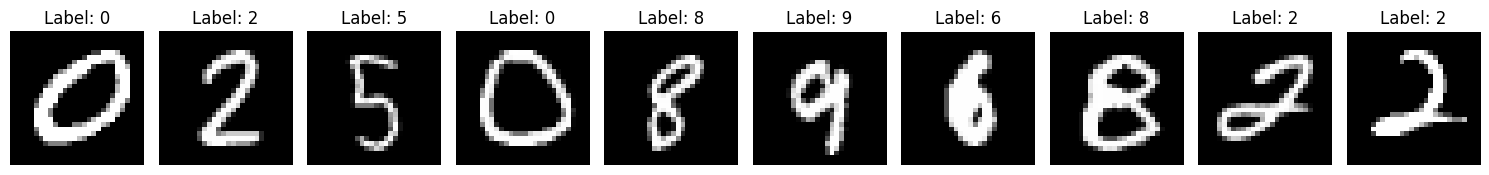

In [4]:
def show_images(loader, num_images=10):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    for idx in range(num_images):
        img = images[idx].numpy().squeeze()
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(f'Label: {labels[idx].item()}')
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

show_images(train_loader_mnist)

### Definir función de entrenamiento

In [5]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc='Entrenando', leave=False):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass y optimización
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

### Definir función de evaluación

In [6]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluando', leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

### Entrenar modelo LeNet-5 en MNIST

In [7]:
# Hiperparámetros
num_epochs = 10
learning_rate = 0.001

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lenet.parameters(), lr=learning_rate)

# Listas para guardar métricas
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

# Entrenamiento
print('Iniciando entrenamiento de LeNet-5 en MNIST...\n')
for epoch in range(num_epochs):
    # Entrenar
    train_loss, train_acc = train_epoch(model_lenet, train_loader_mnist, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Evaluar
    test_loss, test_acc = evaluate(model_lenet, test_loader_mnist, criterion, device)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f'Época [{epoch+1}/{num_epochs}]')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%\n')

print('Entrenamiento completado!')

Iniciando entrenamiento de LeNet-5 en MNIST...



Época [1/10]
  Train Loss: 0.3315, Train Acc: 90.73%
  Test Loss: 0.1112, Test Acc: 96.55%



Época [2/10]
  Train Loss: 0.0870, Train Acc: 97.37%
  Test Loss: 0.0666, Test Acc: 98.02%



Época [3/10]
  Train Loss: 0.0556, Train Acc: 98.34%
  Test Loss: 0.0456, Test Acc: 98.64%



Época [4/10]
  Train Loss: 0.0444, Train Acc: 98.65%
  Test Loss: 0.0425, Test Acc: 98.67%



...

Época [6/10]
  Train Loss: 0.0292, Train Acc: 99.13%
  Test Loss: 0.0374, Test Acc: 98.71%



Época [7/10]
  Train Loss: 0.0249, Train Acc: 99.21%
  Test Loss: 0.0352, Test Acc: 98.78%



Época [8/10]
  Train Loss: 0.0211, Train Acc: 99.35%
  Test Loss: 0.0369, Test Acc: 98.85%



Época [9/10]
  Train Loss: 0.0170, Train Acc: 99.47%
  Test Loss: 0.0349, Test Acc: 98.86%



Época [10/10]
  Train Loss: 0.0146, Train Acc: 99.54%
  Test Loss: 0.0428, Test Acc: 98.61%

Entrenamiento completado!


### Visualizar curvas de aprendizaje

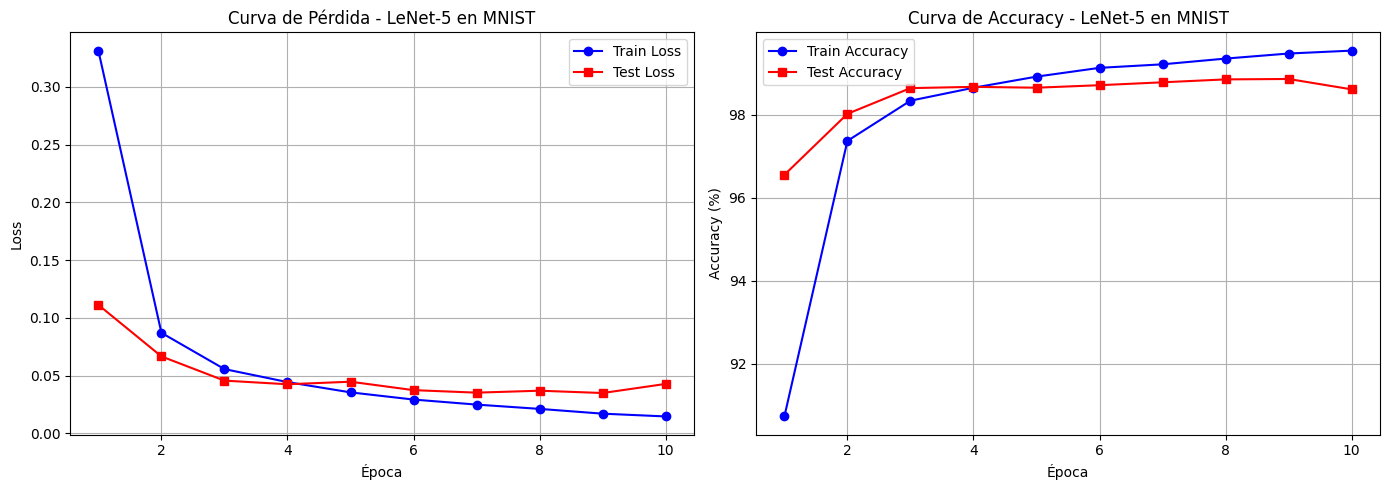


Mejor Test Accuracy: 98.86%
Test Accuracy final: 98.61%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
ax1.plot(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss', marker='o')
ax1.plot(range(1, num_epochs+1), test_losses, 'r-', label='Test Loss', marker='s')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Pérdida - LeNet-5 en MNIST')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(range(1, num_epochs+1), train_accuracies, 'b-', label='Train Accuracy', marker='o')
ax2.plot(range(1, num_epochs+1), test_accuracies, 'r-', label='Test Accuracy', marker='s')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Curva de Accuracy - LeNet-5 en MNIST')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'\nMejor Test Accuracy: {max(test_accuracies):.2f}%')
print(f'Test Accuracy final: {test_accuracies[-1]:.2f}%')

### Matriz de confusión

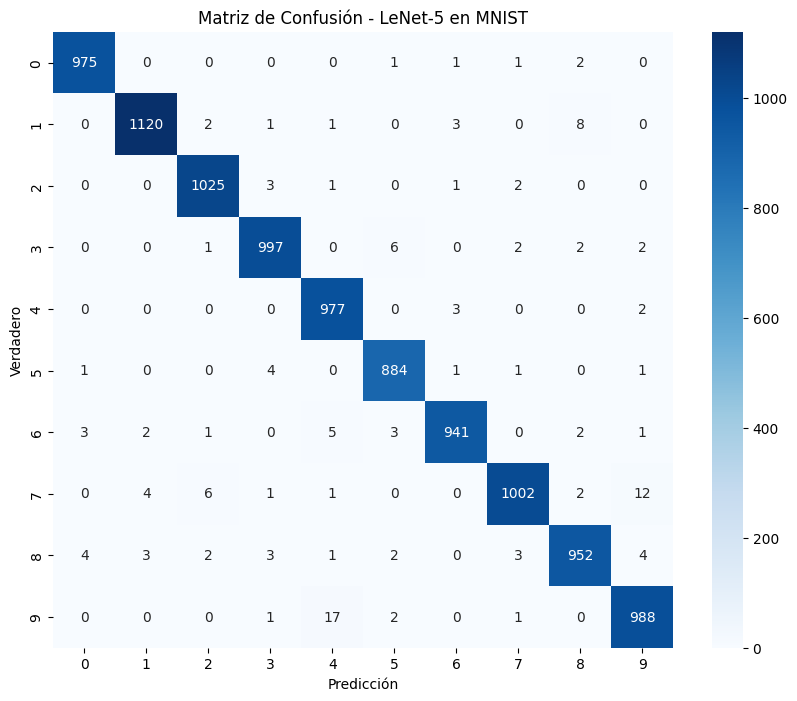


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model_lenet.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_mnist:
        images = images.to(device)
        outputs = model_lenet(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Matriz de confusión
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión - LeNet-5 en MNIST')
plt.show()

print('\nReporte de Clasificación:')
print(classification_report(all_labels, all_predictions,
                          target_names=[str(i) for i in range(10)]))

### Visualizar predicciones

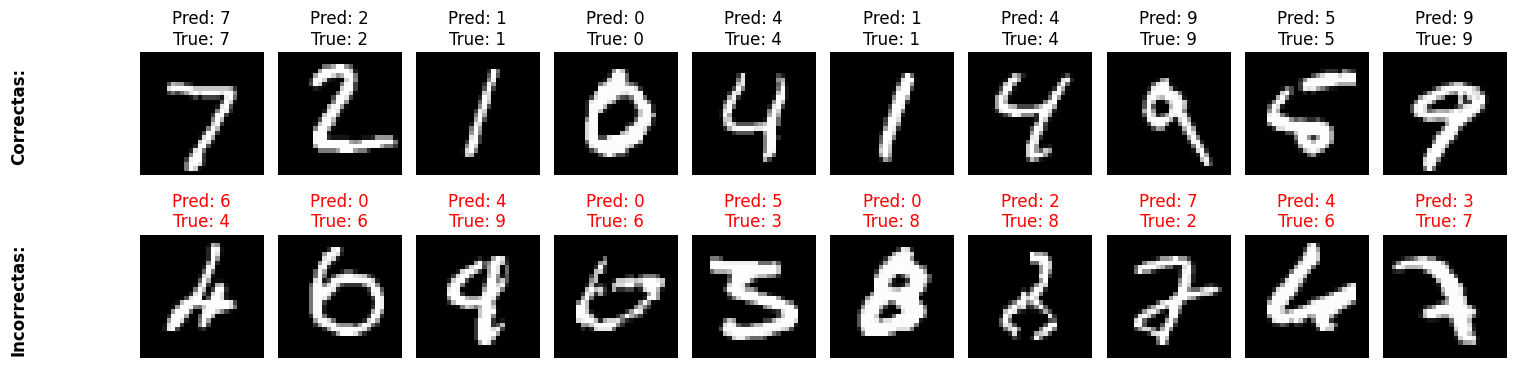

In [10]:
def visualize_predictions(model, test_loader, device, num_images=10):
    model.eval()
    images_shown = 0

    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))

    correct_shown = 0
    incorrect_shown = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            for idx in range(len(images)):
                if correct_shown < num_images and predicted[idx] == labels[idx]:
                    img = images[idx].cpu().numpy().squeeze()
                    axes[0, correct_shown].imshow(img, cmap='gray')
                    axes[0, correct_shown].set_title(f'Pred: {predicted[idx].item()}\nTrue: {labels[idx].item()}')
                    axes[0, correct_shown].axis('off')
                    correct_shown += 1

                if incorrect_shown < num_images and predicted[idx] != labels[idx]:
                    img = images[idx].cpu().numpy().squeeze()
                    axes[1, incorrect_shown].imshow(img, cmap='gray')
                    axes[1, incorrect_shown].set_title(f'Pred: {predicted[idx].item()}\nTrue: {labels[idx].item()}', color='red')
                    axes[1, incorrect_shown].axis('off')
                    incorrect_shown += 1

                if correct_shown >= num_images and incorrect_shown >= num_images:
                    break

            if correct_shown >= num_images and incorrect_shown >= num_images:
                break

    axes[0, 0].text(-30, 14, 'Correctas:', fontsize=12, fontweight='bold', rotation=90, va='center')
    axes[1, 0].text(-30, 14, 'Incorrectas:', fontsize=12, fontweight='bold', rotation=90, va='center')
    plt.tight_layout()
    plt.show()

visualize_predictions(model_lenet, test_loader_mnist, device)

---
## AlexNet para clasificación de imágenes CIFAR10

In [11]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()

        self.features = nn.Sequential(
            # Conv1: adaptado para imágenes 32x32 de CIFAR10
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_alexnet = AlexNet(num_classes=10).to(device)
print(model_alexnet)

total_params = sum(p.numel() for p in model_alexnet.parameters())
trainable_params = sum(p.numel() for p in model_alexnet.parameters() if p.requires_grad)
print(f'\nTotal de parámetros: {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, in

### Cargar y preparar dataset CIFAR10

In [12]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Descargar y cargar datasets
train_dataset_cifar = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset_cifar = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# Crear DataLoaders
batch_size_cifar = 128
train_loader_cifar = DataLoader(
    train_dataset_cifar,
    batch_size=batch_size_cifar,
    shuffle=True,
    num_workers=2
)

test_loader_cifar = DataLoader(
    test_dataset_cifar,
    batch_size=batch_size_cifar,
    shuffle=False,
    num_workers=2
)

# Clases de CIFAR10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Tamaño del conjunto de entrenamiento: {len(train_dataset_cifar)}')
print(f'Tamaño del conjunto de prueba: {len(test_dataset_cifar)}')
print(f'Clases: {classes}')

100%|██████████| 170M/170M [06:52<00:00, 414kB/s]


Tamaño del conjunto de entrenamiento: 50000
Tamaño del conjunto de prueba: 10000
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Visualizar muestras de CIFAR10

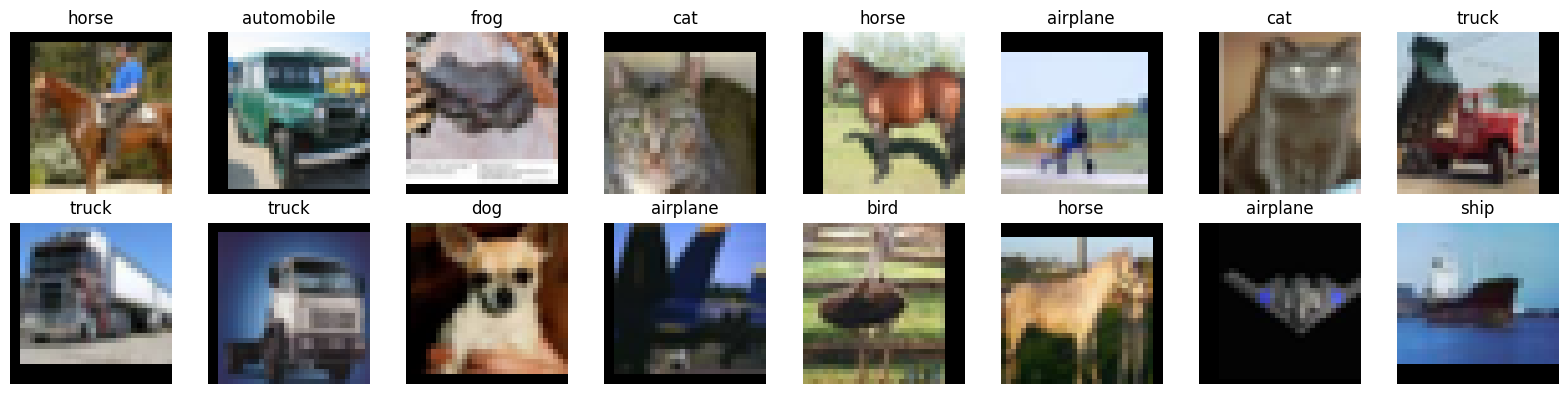

In [13]:
def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Visualizar imágenes de CIFAR10
dataiter = iter(train_loader_cifar)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for idx in range(16):
    row = idx // 8
    col = idx % 8

    img = denormalize(images[idx].clone(),
                     mean=[0.4914, 0.4822, 0.4465],
                     std=[0.2470, 0.2435, 0.2616])
    img = img.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1)

    axes[row, col].imshow(img)
    axes[row, col].set_title(classes[labels[idx]])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Entrenar modelo AlexNet en CIFAR10

In [15]:
num_epochs_alex = 30
learning_rate_alex = 0.001

criterion_alex = nn.CrossEntropyLoss()
optimizer_alex = optim.Adam(model_alexnet.parameters(), lr=learning_rate_alex, weight_decay=5e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_alex, mode='min',
                                                  factor=0.5, patience=3)

train_losses_alex, train_accuracies_alex = [], []
test_losses_alex, test_accuracies_alex = [], []

print('Iniciando entrenamiento de AlexNet en CIFAR10...\n')
best_acc = 0.0

for epoch in range(num_epochs_alex):
    train_loss, train_acc = train_epoch(model_alexnet, train_loader_cifar,
                                       criterion_alex, optimizer_alex, device)
    train_losses_alex.append(train_loss)
    train_accuracies_alex.append(train_acc)

    test_loss, test_acc = evaluate(model_alexnet, test_loader_cifar, criterion_alex, device)
    test_losses_alex.append(test_loss)
    test_accuracies_alex.append(test_acc)

    scheduler.step(test_loss)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model_alexnet.state_dict(), 'best_alexnet_cifar10.pth')

    print(f'Época [{epoch+1}/{num_epochs_alex}]')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(f'  Mejor Test Acc: {best_acc:.2f}%\n')

print('Entrenamiento completado!')
print(f'Mejor Test Accuracy alcanzado: {best_acc:.2f}%')

Iniciando entrenamiento de AlexNet en CIFAR10...



Época [1/30]
  Train Loss: 1.7978, Train Acc: 31.38%
  Test Loss: 1.4528, Test Acc: 45.91%
  Mejor Test Acc: 45.91%



Época [2/30]
  Train Loss: 1.3863, Train Acc: 48.79%
  Test Loss: 1.1902, Test Acc: 56.08%
  Mejor Test Acc: 56.08%



Época [3/30]
  Train Loss: 1.2125, Train Acc: 56.34%
  Test Loss: 1.1560, Test Acc: 59.05%
  Mejor Test Acc: 59.05%



Época [4/30]
  Train Loss: 1.0924, Train Acc: 61.11%
  Test Loss: 0.9787, Test Acc: 64.82%
  Mejor Test Acc: 64.82%



...

Época [26/30]
  Train Loss: 0.5496, Train Acc: 81.65%
  Test Loss: 0.6246, Test Acc: 79.33%
  Mejor Test Acc: 81.00%



Época [27/30]
  Train Loss: 0.5438, Train Acc: 81.79%
  Test Loss: 0.6293, Test Acc: 79.62%
  Mejor Test Acc: 81.00%



Época [28/30]
  Train Loss: 0.5428, Train Acc: 81.85%
  Test Loss: 0.5670, Test Acc: 81.06%
  Mejor Test Acc: 81.06%



Época [29/30]
  Train Loss: 0.5358, Train Acc: 82.19%
  Test Loss: 0.5958, Test Acc: 80.62%
  Mejor Test Acc: 81.06%



Época [30/30]
  Train Loss: 0.4614, Train Acc: 84.35%
  Test Loss: 0.4977, Test Acc: 83.16%
  Mejor Test Acc: 83.16%

Entrenamiento completado!
Mejor Test Accuracy alcanzado: 83.16%


### Visualizar curvas de aprendizaje de AlexNet

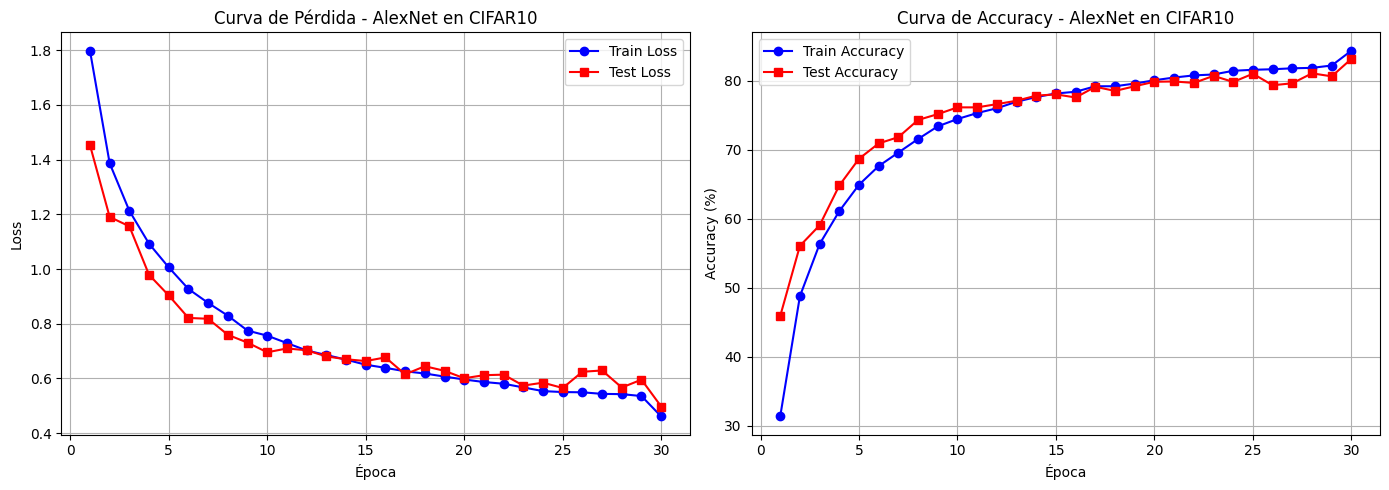


Mejor Test Accuracy: 83.16%
Test Accuracy final: 83.16%


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
ax1.plot(range(1, num_epochs_alex+1), train_losses_alex, 'b-', label='Train Loss', marker='o')
ax1.plot(range(1, num_epochs_alex+1), test_losses_alex, 'r-', label='Test Loss', marker='s')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Pérdida - AlexNet en CIFAR10')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(range(1, num_epochs_alex+1), train_accuracies_alex, 'b-', label='Train Accuracy', marker='o')
ax2.plot(range(1, num_epochs_alex+1), test_accuracies_alex, 'r-', label='Test Accuracy', marker='s')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Curva de Accuracy - AlexNet en CIFAR10')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'\nMejor Test Accuracy: {max(test_accuracies_alex):.2f}%')
print(f'Test Accuracy final: {test_accuracies_alex[-1]:.2f}%')

### Matriz de confusión y métricas detalladas de AlexNet

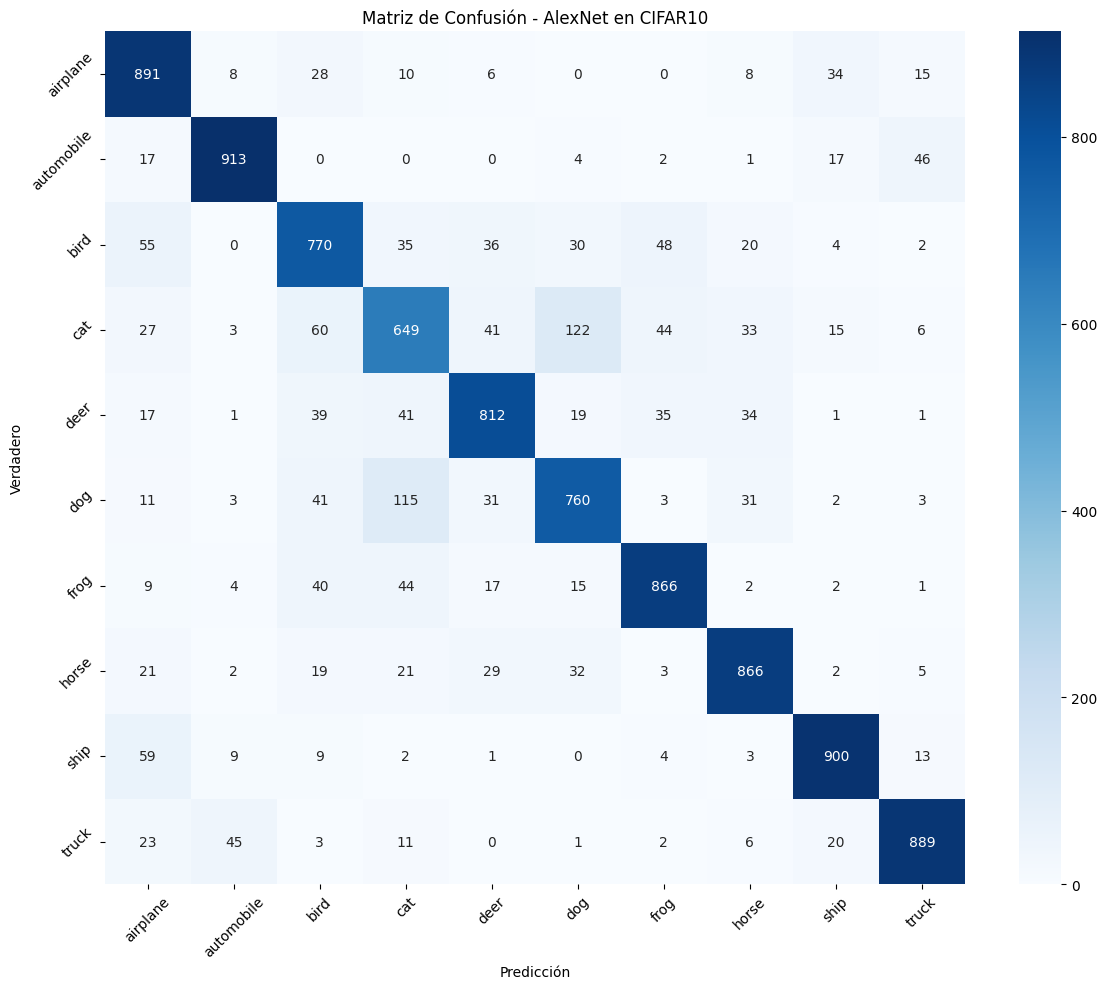


Reporte de Clasificación:
              precision    recall  f1-score   support

    airplane       0.79      0.89      0.84      1000
  automobile       0.92      0.91      0.92      1000
        bird       0.76      0.77      0.77      1000
         cat       0.70      0.65      0.67      1000
        deer       0.83      0.81      0.82      1000
         dog       0.77      0.76      0.77      1000
        frog       0.86      0.87      0.86      1000
       horse       0.86      0.87      0.86      1000
        ship       0.90      0.90      0.90      1000
       truck       0.91      0.89      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



In [17]:
model_alexnet.load_state_dict(torch.load('best_alexnet_cifar10.pth'))
model_alexnet.eval()

all_predictions_alex = []
all_labels_alex = []

with torch.no_grad():
    for images, labels in test_loader_cifar:
        images = images.to(device)
        outputs = model_alexnet(images)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions_alex.extend(predicted.cpu().numpy())
        all_labels_alex.extend(labels.numpy())

# Matriz de confusión
cm_alex = confusion_matrix(all_labels_alex, all_predictions_alex)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_alex, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión - AlexNet en CIFAR10')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nReporte de Clasificación:')
print(classification_report(all_labels_alex, all_predictions_alex,
                          target_names=classes))

### Visualizar predicciones de AlexNet

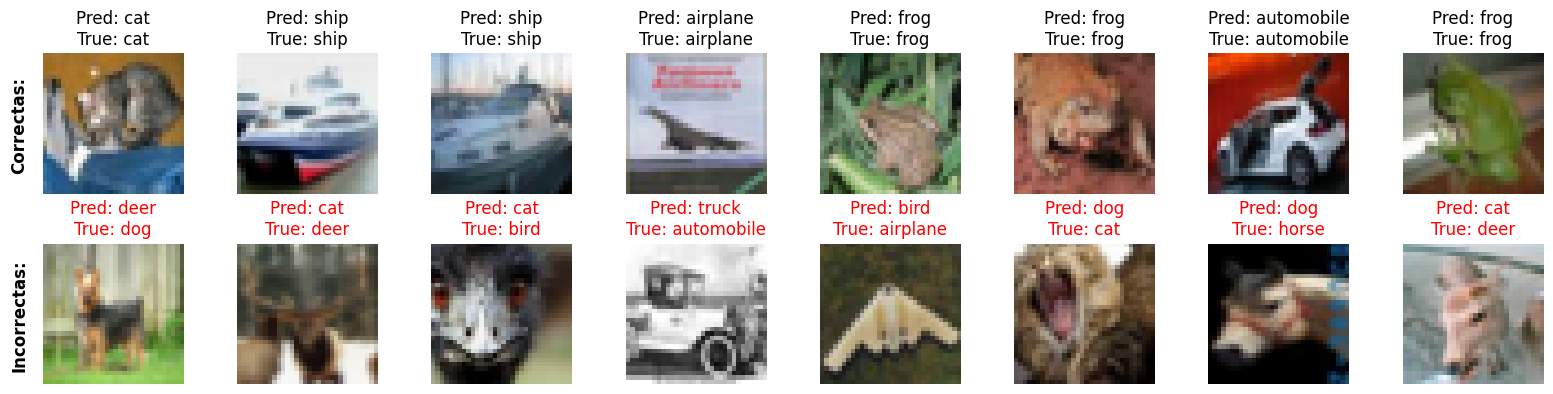

In [18]:
def visualize_predictions_cifar(model, test_loader, device, classes, num_images=8):
    model.eval()

    fig, axes = plt.subplots(2, num_images, figsize=(16, 4))

    correct_shown = 0
    incorrect_shown = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            _, predicted = torch.max(outputs, 1)

            for idx in range(len(images)):
                if correct_shown < num_images and predicted[idx] == labels[idx]:
                    img = denormalize(images[idx].clone(),
                                    mean=[0.4914, 0.4822, 0.4465],
                                    std=[0.2470, 0.2435, 0.2616])
                    img = img.numpy().transpose((1, 2, 0))
                    img = np.clip(img, 0, 1)

                    axes[0, correct_shown].imshow(img)
                    axes[0, correct_shown].set_title(f'Pred: {classes[predicted[idx]]}\nTrue: {classes[labels[idx]]}')
                    axes[0, correct_shown].axis('off')
                    correct_shown += 1

                if incorrect_shown < num_images and predicted[idx] != labels[idx]:
                    img = denormalize(images[idx].clone(),
                                    mean=[0.4914, 0.4822, 0.4465],
                                    std=[0.2470, 0.2435, 0.2616])
                    img = img.numpy().transpose((1, 2, 0))
                    img = np.clip(img, 0, 1)

                    axes[1, incorrect_shown].imshow(img)
                    axes[1, incorrect_shown].set_title(f'Pred: {classes[predicted[idx]]}\nTrue: {classes[labels[idx]]}', color='red')
                    axes[1, incorrect_shown].axis('off')
                    incorrect_shown += 1

                if correct_shown >= num_images and incorrect_shown >= num_images:
                    break

            if correct_shown >= num_images and incorrect_shown >= num_images:
                break

    axes[0, 0].text(-8, 16, 'Correctas:', fontsize=12, fontweight='bold', rotation=90, va='center')
    axes[1, 0].text(-8, 16, 'Incorrectas:', fontsize=12, fontweight='bold', rotation=90, va='center')
    plt.tight_layout()
    plt.show()

visualize_predictions_cifar(model_alexnet, test_loader_cifar, device, classes)

## Comparación de arquitecturas

In [ ]:
print('='*80)
print('COMPARACIÓN DE ARQUITECTURAS: LeNet-5 vs AlexNet')
print('='*80)

# LeNet-5
lenet_params = sum(p.numel() for p in model_lenet.parameters())
lenet_best_acc = max(test_accuracies)

# AlexNet
alexnet_params = sum(p.numel() for p in model_alexnet.parameters())
alexnet_best_acc = max(test_accuracies_alex)

print(f'\n{"Característica":<30} {"LeNet-5":<20} {"AlexNet":<20}')
print('-'*80)
print(f'{"Dataset":<30} {"MNIST":<20} {"CIFAR10":<20}')
print(f'{"Tamaño de entrada":<30} {"28x28x1":<20} {"32x32x3":<20}')
print(f'{"Capas convolucionales":<30} {"2":<20} {"5":<20}')
print(f'{"Capas FC":<30} {"3":<20} {"3":<20}')
print(f'{"Parámetros totales":<30} {f"{lenet_params:,}":<20} {f"{alexnet_params:,}":<20}')
print(f'{"Función de activación":<30} {"Tanh":<20} {"ReLU":<20}')
print(f'{"Pooling":<30} {"Average":<20} {"Max":<20}')
print(f'{"Regularización":<30} {"Ninguna":<20} {"Dropout (0.5)":<20}')
print(f'{"Data augmentation":<30} {"No":<20} {"Sí":<20}')
print(f'{"Mejor Test Accuracy":<30} {f"{lenet_best_acc:.2f}%":<20} {f"{alexnet_best_acc:.2f}%":<20}')
print(f'{"Año de publicación":<30} {"1998":<20} {"2012":<20}')
print('='*80)

COMPARACIÓN DE ARQUITECTURAS: LeNet-5 vs AlexNet

Característica                 LeNet-5              AlexNet             
--------------------------------------------------------------------------------
Dataset                        MNIST                CIFAR10             
Tamaño de entrada              28x28x1              32x32x3             
Capas convolucionales          2                    5                   
Capas FC                       3                    3                   
Parámetros totales             61,706               35,855,178          
Función de activación          Tanh                 ReLU                
Pooling                        Average              Max                 
Regularización                 Ninguna              Dropout (0.5)       
Data augmentation              No                   Sí                  
Mejor Test Accuracy            98.86%               83.16%              
Año de publicación             1998                 2012          

---

### a. ¿Cuál es la diferencia principal entre ambas arquitecturas?

Las diferencias principales entre LeNet-5 y AlexNet son:

#### 1. Profundidad y Complejidad
- LeNet-5: Arquitectura poco profunda con solo 2 capas convolucionales y ~60K parámetros. Fue diseñada para problemas simples como reconocimiento de dígitos en imágenes de baja resolución.
- AlexNet: Arquitectura mucho más profunda con 5 capas convolucionales y ~60M parámetros (1000x más). Diseñada para problemas complejos como ImageNet con 1000 clases.

#### 2. Función de Activación
- LeNet-5: Utiliza tanh o sigmoid, funciones que pueden sufrir de gradientes que se desvanecen en redes profundas.
- AlexNet: Introdujo el uso masivo de ReLU (Rectified Linear Unit), que acelera el entrenamiento y mitiga el problema de gradientes evanescentes.

#### 3. Regularización
- LeNet-5: No utiliza técnicas de regularización explícitas.
- AlexNet: Incorpora Dropout (0.5 en capas FC) para prevenir overfitting, crucial para redes grandes.

### b. ¿Podría usarse LeNet-5 para un problema como el que resolvió usando AlexNet? ¿Y viceversa?

#### LeNet-5 para CIFAR10 (problema de AlexNet)
LeNet-5 funcionaría pero sería subóptima para CIFAR10. Es como usar una herramienta simple para un trabajo complejo: funciona parcialmente pero no alcanza buenos resultados.

#### AlexNet para MNIST (problema de LeNet-5)
 AlexNet puede adaptarse fácilmente a MNIST ajustando canales de entrada (3→1) y reduciendo el tamaño de entrada. Probablemente alcanzaría ~99%+ accuracy, similar o mejor que LeNet-5.


### c. Indique claramente qué le pareció más interesante de cada arquitectura

#### LeNet-5:

1. Simplicidad efectiva: Me fascina cómo LeNet-5 logra ~98-99% accuracy en MNIST con solo 60K parámetros. Demuestra que no siempre se necesita un modelo gigante para resolver problemas específicos. En la era de modelos con billones de parámetros, LeNet-5 es un recordatorio de que la eficiencia importa.

2. Visión adelantada a su época: Propuesta en 1998, LeNet-5 ya contenía las ideas fundamentales de las CNNs modernas: convolución→pooling→FC. Yann LeCun esencialmente "resolvió" la arquitectura básica de CNNs décadas antes de que el hardware permitiera escalarla.

### AlexNet:

1. Catalizador de la revolución del Deep Learning: AlexNet no solo ganó ImageNet 2012, la ganó con una ventaja tan aplastante (15.3% error vs 26.2% del segundo lugar) que convenció a toda la comunidad de que el deep learning era el futuro. Es un caso de estudio de cómo un paper puede cambiar una industria entera.

2. Impacto en la industria: Post-AlexNet, empresas masivamente invirtieron en deep learning. Es difícil exagerar su impacto: sin AlexNet, quizás no tendríamos GPT, DALL-E, o Claude hoy.

# TASK 2